###  Tarea  3 Componente práctico – Prácticas simulada Diagnóstico y Validación de Modelos

Estudiante: Ivan Ramiro Quiroga Castañeda


### Definición del modelo de regresión lineal múltiple

In [4]:

import pandas as pd
import numpy as np

df = pd.read_csv("Anexo 1 - Base de Datos dynamic_pricing.csv")

# Visualización inicial
df.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


In [8]:

# creacion de variables para el modelo

# Variable dependiente
df["Trip_Rating"] = df["Average_Ratings"]

# Variable independiente (distancia aproximada)
df["Trip_Distance"] = df["Expected_Ride_Duration"]

# Transformación de lealtad del cliente a variable numérica ordinal
mapa_lealtad = {
    "Regular": 1,
    "Silver": 2,
    "Gold": 3
}

df["Customer_Loyalty"] = df["Customer_Loyalty_Status"].map(mapa_lealtad)

# Selección de variables relevantes
df_model = df[["Trip_Rating", "Trip_Distance", "Number_of_Riders", "Customer_Loyalty"]].copy()

# Eliminar nulos
df_model = df_model.dropna()

# Verificación
df_model.head()

,Trip_Rating,Trip_Distance,Number_of_Riders,Customer_Loyalty
0,4.47,90,90,2
1,4.06,43,58,2
2,3.99,76,42,2
3,4.31,134,89,1
4,3.77,149,78,1



## Estimación del modelo de regresión lineal múltiple


In [10]:

# Ajuste  del modelo de  regresion

import statsmodels.api as sm

# Variables independientes (X) y dependiente (y)
X = df_model[["Trip_Distance", "Number_of_Riders", "Customer_Loyalty"]]
y = df_model["Trip_Rating"]

# Agregar intercepto
X = sm.add_constant(X)

# Ajustar modelo
modelo = sm.OLS(y, X).fit()

# Resumen del modelo
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:            Trip_Rating   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.4789
Date:                Sun, 12 Apr 2026   Prob (F-statistic):              0.697
Time:                        17:16:22   Log-Likelihood:                -587.10
No. Observations:                1000   AIC:                             1182.
Df Residuals:                     996   BIC:                             1202.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                4.3009      0.060  

## Diagnóstico de multicolinealidad

In [12]:

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Variables independientes
X_vif = df_model[["Trip_Distance", "Number_of_Riders", "Customer_Loyalty"]]

# Agregar constante
X_vif = sm.add_constant(X_vif)

# Calcular VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data

,Variable,VIF
0,const,18.804311
1,Trip_Distance,1.000303
2,Number_of_Riders,1.004056
3,Customer_Loyalty,1.003870


## Evaluación de supuestos del modelo

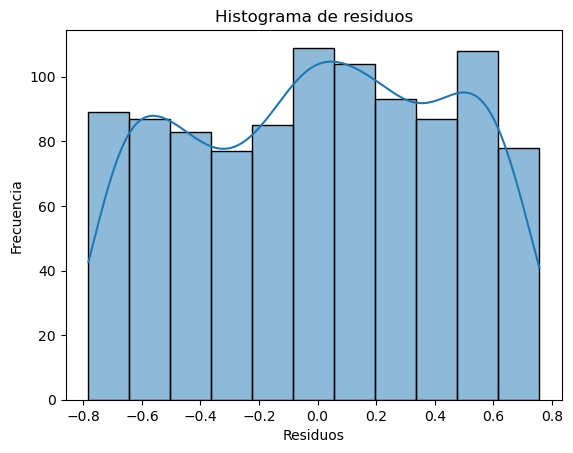

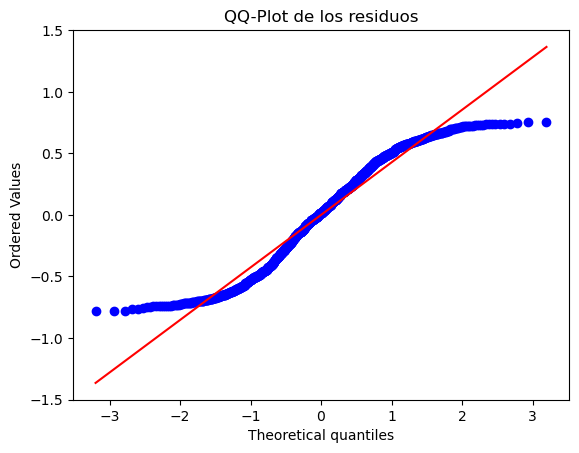

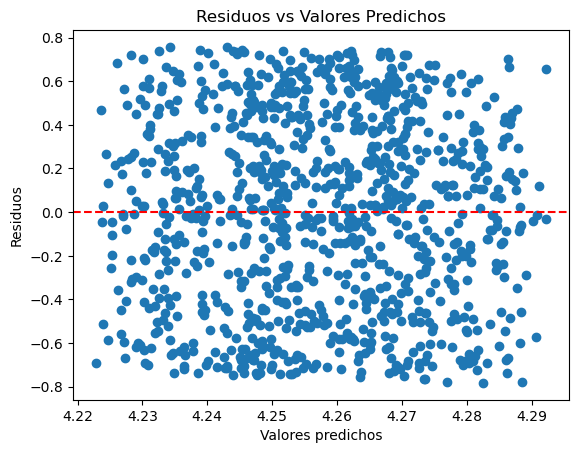

In [20]:

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Obtener residuos y valores predichos
residuos = modelo.resid
valores_predichos = modelo.fittedvalues

# Histograma de residuos

plt.figure()
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.show()

# QQ-PLOT

plt.figure()
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("QQ-Plot de los residuos")
plt.show()

# Residuos vs predichos

plt.figure()
plt.scatter(valores_predichos, residuos)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residuos vs Valores Predichos")
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.show()

## Mejora del modelo

In [22]:

# Aplicar transformación logarítmica a la distancia
df_model["Log_Trip_Distance"] = np.log(df_model["Trip_Distance"] + 1)

# Nuevas variables
X2 = df_model[["Log_Trip_Distance", "Number_of_Riders", "Customer_Loyalty"]]
y2 = df_model["Trip_Rating"]

# Agregar constante
X2 = sm.add_constant(X2)

# Ajustar nuevo modelo
modelo_mejorado = sm.OLS(y2, X2).fit()

# Resumen
print(modelo_mejorado.summary())

                            OLS Regression Results                            
Dep. Variable:            Trip_Rating   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.7633
Date:                Sun, 12 Apr 2026   Prob (F-statistic):              0.515
Time:                        18:51:35   Log-Likelihood:                -586.67
No. Observations:                1000   AIC:                             1181.
Df Residuals:                     996   BIC:                             1201.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 4.3826      0.10

## Validación del modelo mediante remuestreo Bootstrap

In [21]:

# Número de iteraciones
n_boot = 1000

# Lista para guardar coeficientes
coeficientes = []

for i in range(n_boot):
    muestra = df_model.sample(n=len(df_model), replace=True)
    
    X_b = muestra[["Log_Trip_Distance", "Number_of_Riders", "Customer_Loyalty"]]
    y_b = muestra["Trip_Rating"]
    
    X_b = sm.add_constant(X_b)
    
    modelo_b = sm.OLS(y_b, X_b).fit()
    
    coeficientes.append(modelo_b.params)

# Convertir a DataFrame
coef_df = pd.DataFrame(coeficientes)

# Intervalos de confianza
intervalos = coef_df.quantile([0.025, 0.975])

coef_df.head(), intervalos

(      const  Log_Trip_Distance  Number_of_Riders  Customer_Loyalty
 0  4.285288          -0.018735          0.001242         -0.009043
 1  4.513219          -0.061915          0.000837         -0.017264
 2  4.343491          -0.021620          0.000243         -0.007306
 3  4.152060           0.007990          0.001754         -0.010550
 4  4.183636           0.012217          0.000572         -0.003921,
           const  Log_Trip_Distance  Number_of_Riders  Customer_Loyalty
 0.025  4.191206          -0.059366         -0.001065         -0.051806
 0.975  4.581648           0.016471          0.001243          0.015896)